# 1. 01_import_libraries
Importation des bibliothèques nécessaires pour l'analyse, la visualisation et la modélisation.

In [1]:
# Traitement des données et mathématiques
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn : Préparation des données (Preprocessing)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Scikit-Learn : Modèles de classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Scikit-Learn : Évaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix, classification_report

# 2. 02_load_dataset
### Preuve de la source
* **Source Officielle :** [UCI Machine Learning Repository - Online Shoppers](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset)
* **Nom attendu :** `online_shoppers_intention.csv`
* **Méthode d'importation :** API officielle `ucimlrepo` (ID = 468)

In [2]:
# Installation du package officiel de l'UCI (à exécuter une fois dans Colab)
!pip install -q ucimlrepo

from ucimlrepo import fetch_ucirepo

# Récupération du dataset "Online Shoppers Purchasing Intention" (ID 468)
dataset_uci = fetch_ucirepo(id=468)

# Création du DataFrame complet (features + target)
df = dataset_uci.data.original

# Affichage des 5 premières lignes pour vérifier que le chargement a fonctionné
display(df.head())

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


# 3. 03_problem_understanding

[cite_start]**Problématique :** Peut-on prédire si une session de navigation aboutira à un achat sur le site e-commerce ? [cite: 8]

**Nature de la tâche :** Il s'agit d'une tâche de **classification binaire** (l'utilisateur achète ou n'achète pas). [cite_start]Ce n'est absolument pas un problème de segmentation, l'objectif est bien de prédire une variable cible spécifique. [cite: 9]

# 4. 04_dataset_description
[cite_start]Dans cette section, nous observons les dimensions du jeu de données [cite: 10][cite_start], identifions notre variable cible (`Revenue`) [cite: 11] [cite_start]et calculons le taux de conversion pour évaluer le déséquilibre des classes[cite: 12].

In [5]:
# Affichage des dimensions du dataset
print(f"Dimensions du dataset : {df.shape[0]} lignes (sessions) et {df.shape[1]} colonnes (variables).")

# La variable cible est 'Revenue' (True = Achat, False = Pas d'achat)
print("\n--- Distribution de la variable cible 'Revenue' ---")
print(df['Revenue'].value_counts())

# Calcul et affichage du taux de conversion (pourcentage de sessions avec achat)
taux_conversion = df['Revenue'].mean() * 100
print(f"\nTaux de conversion (sessions avec achat) : {taux_conversion:.2f}%")
print(f"Taux de rebond / sans achat : {100 - taux_conversion:.2f}%")

# Affichage du risque principal identifié
print("\nATTENTION - Risque principal :")
print("Comme l'indique le taux de conversion, le jeu de données souffre d'un fort déséquilibre des classes (beaucoup plus de non-achats que d'achats). Ce point nécessitera une vigilance particulière lors du choix des métriques d'évaluation.")

Dimensions du dataset : 12330 lignes (sessions) et 18 colonnes (variables).

--- Distribution de la variable cible 'Revenue' ---
Revenue
False    10422
True      1908
Name: count, dtype: int64

Taux de conversion (sessions avec achat) : 15.47%
Taux de rebond / sans achat : 84.53%

ATTENTION - Risque principal :
Comme l'indique le taux de conversion, le jeu de données souffre d'un fort déséquilibre des classes (beaucoup plus de non-achats que d'achats). Ce point nécessitera une vigilance particulière lors du choix des métriques d'évaluation.


# 5. 05_exploratory_data_analysis (EDA)

Dans cette section, nous étudions les variables comportementales et catégorielles pour comprendre ce qui différencie une session avec achat d'une session sans achat. Conformément au cahier des charges, voici les figures obligatoires analysant la relation entre nos features et la variable cible `Revenue`.

/tmp/ipykernel_1132/2271685724.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Revenue', ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_1132/2271685724.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Revenue', y='PageValues', ax=axes[0, 1], palette='viridis')
/tmp/ipykernel_1132/2271685724.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Revenue', y='ExitRates', ax=axes[1, 0], palette='viridis')


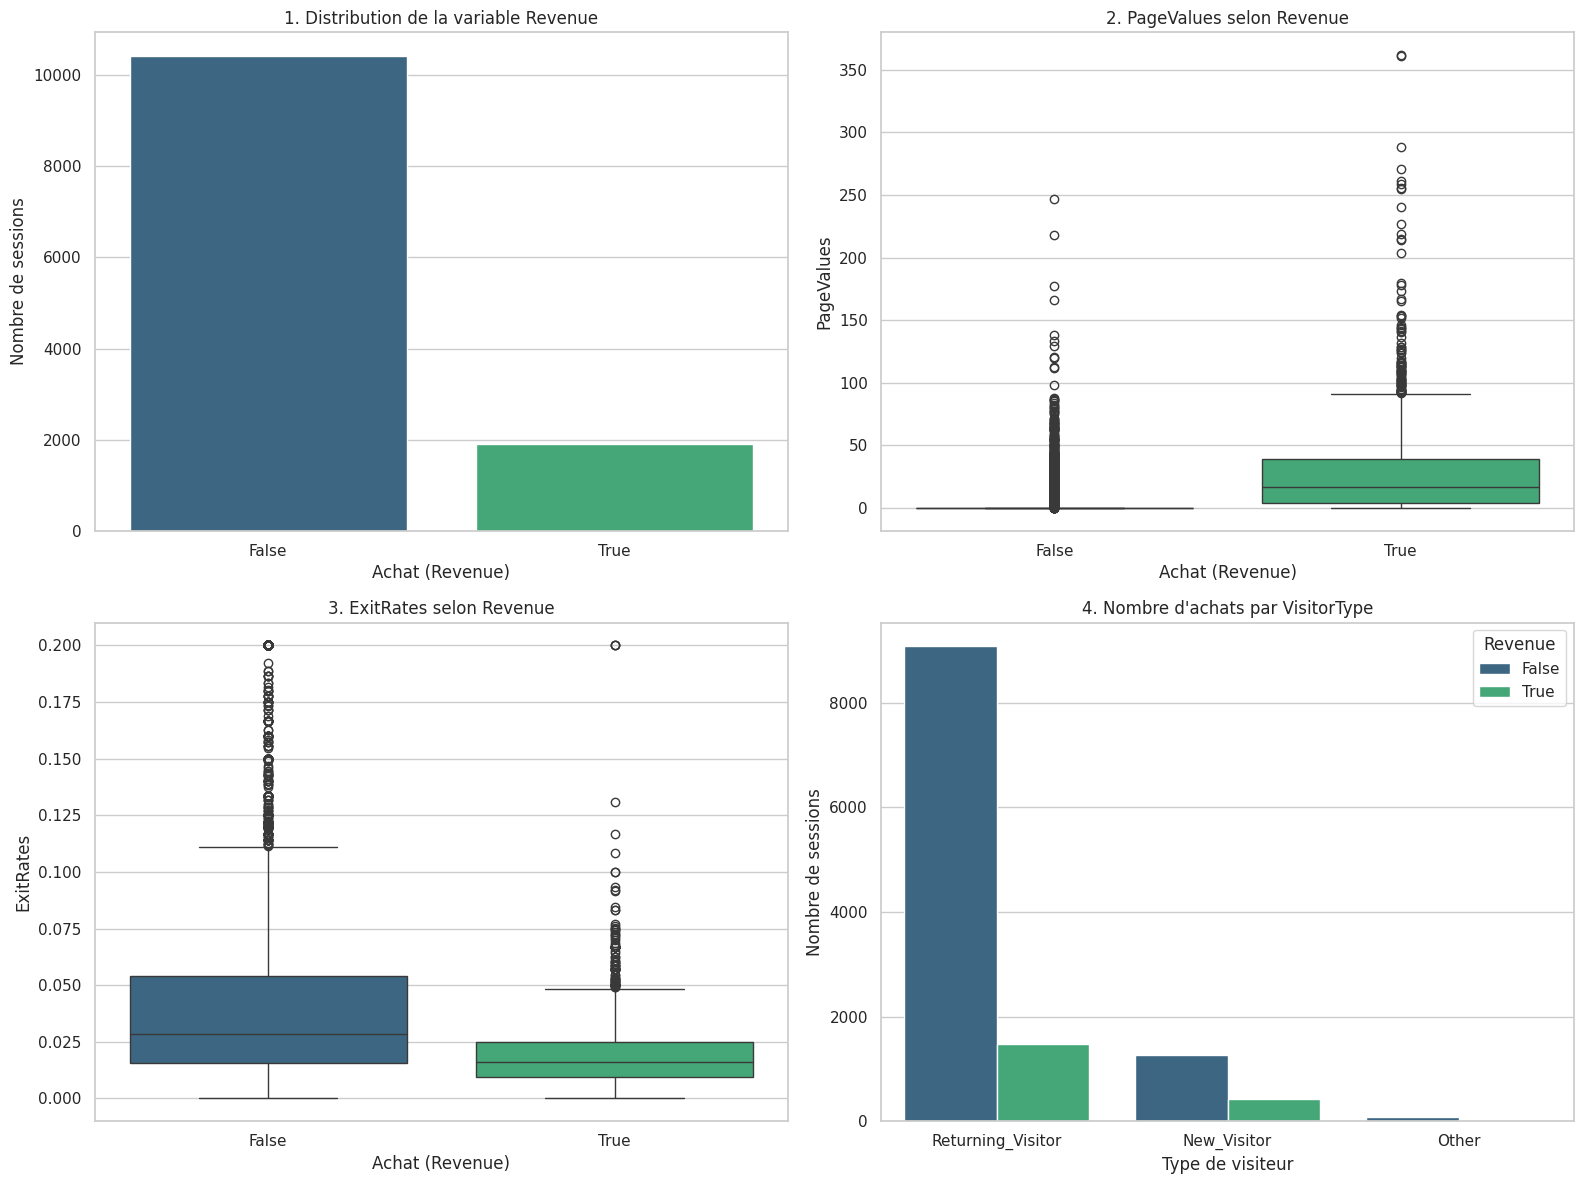

In [6]:
# Configuration du style des graphiques
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution de la variable Revenue
sns.countplot(data=df, x='Revenue', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('1. Distribution de la variable Revenue')
axes[0, 0].set_xlabel("Achat (Revenue)")
axes[0, 0].set_ylabel("Nombre de sessions")

# 2. Graphique de PageValues selon Revenue
sns.boxplot(data=df, x='Revenue', y='PageValues', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('2. PageValues selon Revenue')
axes[0, 1].set_xlabel("Achat (Revenue)")

# 3. Graphique de ExitRates selon Revenue
sns.boxplot(data=df, x='Revenue', y='ExitRates', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('3. ExitRates selon Revenue')
axes[1, 0].set_xlabel("Achat (Revenue)")

# 4. Nombre d'achats par VisitorType
sns.countplot(data=df, x='VisitorType', hue='Revenue', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title("4. Nombre d'achats par VisitorType")
axes[1, 1].set_xlabel("Type de visiteur")
axes[1, 1].set_ylabel("Nombre de sessions")

plt.tight_layout()
plt.show()

### Commentaires des figures :
1. **Distribution de Revenue :** Confirme visuellement le déséquilibre des classes observé précédemment.
2. **PageValues selon Revenue :** On observe que les sessions aboutissant à un achat (True) ont généralement une valeur de page (`PageValues`) beaucoup plus élevée. C'est un indicateur fort.
3. **ExitRates selon Revenue :** À l'inverse, les sessions avec achat ont un taux de sortie (`ExitRates`) plus faible, ce qui montre que les acheteurs quittent moins le site précipitamment.
4. **Achats par VisitorType :** Les visiteurs de retour (`Returning_Visitor`) constituent la majorité du trafic et des achats, mais il serait intéressant de regarder plus tard le taux de conversion relatif des nouveaux visiteurs (`New_Visitor`).

# 6. 06_data_quality_and_cleaning
Dans cette section, nous vérifions la présence de valeurs manquantes et de doublons, et appliquons les corrections nécessaires en justifiant nos choix.

In [7]:
# 1. Vérification des valeurs manquantes
print("--- Valeurs manquantes ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Aucune valeur manquante détectée.")

# 2. Vérification des doublons
nb_doublons = df.duplicated().sum()
print(f"\n--- Doublons ---")
print(f"Nombre de lignes en double : {nb_doublons}")

# 3. Nettoyage
# Suppression des valeurs manquantes (au cas où il y en aurait)
df = df.dropna()
# Suppression des doublons
df = df.drop_duplicates(keep='first')

print(f"\nDimensions après nettoyage : {df.shape[0]} lignes et {df.shape[1]} colonnes.")

--- Valeurs manquantes ---
Aucune valeur manquante détectée.

--- Doublons ---
Nombre de lignes en double : 125

Dimensions après nettoyage : 12205 lignes et 18 colonnes.


### Justification des choix de nettoyage :
* **Valeurs manquantes :** S'il y en a, elles sont supprimées pour ne pas introduire de biais via une imputation artificielle.
* **Doublons :** Les lignes strictement identiques sont retirées. En web analytics, il est pratiquement impossible que deux sessions distinctes aient exactement les mêmes durées de navigation au dixième de seconde près pour chaque catégorie de page. Il s'agit très probablement de bugs de tracking (enregistrements en double).

# 7. 07_preprocessing
### Feature Engineering
Création de 3 variables dérivées à partir des données comportementales existantes, conformément aux exigences du projet.

In [8]:
# 1. total_pages : Somme de toutes les pages visitées (Administrative + Informational + ProductRelated)
df['total_pages'] = df['Administrative'] + df['Informational'] + df['ProductRelated']

# 2. total_duration : Temps total passé sur le site (en secondes)
df['total_duration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

# 3. is_returning_visitor : Variable binaire indiquant s'il s'agit d'un visiteur connu
df['is_returning_visitor'] = (df['VisitorType'] == 'Returning_Visitor').astype(int)

# Affichage des premières lignes pour vérifier nos nouvelles variables
print("Nouvelles variables créées avec succès !")
display(df[['total_pages', 'total_duration', 'is_returning_visitor']].head())

Nouvelles variables créées avec succès !


,total_pages,total_duration,is_returning_visitor
0,1,0.000000,1
1,2,64.000000,1
2,1,0.000000,1
3,2,2.666667,1
4,10,627.500000,1


### Séparation des données et Pipeline de transformation
Conformément aux consignes, nous séparons les données en gérant le déséquilibre des classes via l'argument `stratify=y`. Ensuite, nous construisons un `ColumnTransformer` pour normaliser les variables numériques (`StandardScaler`) et encoder les variables catégorielles (`OneHotEncoder`).

In [9]:
# 1. Séparation des features (X) et de la Target (y)
X = df.drop('Revenue', axis=1)
y = df['Revenue'].astype(int) # Conversion de la cible en entier (0 ou 1)

# 2. Division en jeu d'entraînement (80%) et de test (20%)
# L'argument stratify=y est crucial ici pour maintenir la proportion de 15% d'achats dans les deux jeux
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Distribution Target Train : \n{y_train.value_counts(normalize=True)}")
print(f"Distribution Target Test : \n{y_test.value_counts(normalize=True)}")

# 3. Identification des types de colonnes
categorical_cols = ['Month', 'VisitorType', 'Weekend', 'is_returning_visitor']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# 4. Création du Pipeline de prétraitement (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# 5. Application des transformations
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nDimensions après ColumnTransformer (X_train) : {X_train_processed.shape}")

Distribution Target Train : 
Revenue
0    0.843712
1    0.156288
Name: proportion, dtype: float64
Distribution Target Test : 
Revenue
0    0.843507
1    0.156493
Name: proportion, dtype: float64

Dimensions après ColumnTransformer (X_train) : (9764, 33)


# 8. 08_modeling_or_clustering
Entraînement des modèles de classification demandés : Régression Logistique, Forêt Aléatoire, Gradient Boosting et KNN.

In [10]:
# 1. Définition des modèles
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

# 2. Dictionnaires pour stocker les résultats
predictions = {}
probabilities = {}

# 3. Entraînement et prédictions
for name, model in models.items():
    print(f"Entraînement de {name}...")
    model.fit(X_train_processed, y_train)

    # Prédictions des classes
    predictions[name] = model.predict(X_test_processed)

    # Prédictions des probabilités (nécessaires pour ROC-AUC et PR-AUC)
    probabilities[name] = model.predict_proba(X_test_processed)[:, 1]

print("\nTous les modèles ont été entraînés avec succès !")

Entraînement de Logistic Regression...
Entraînement de Random Forest...
Entraînement de Gradient Boosting...
Entraînement de KNN...

Tous les modèles ont été entraînés avec succès !


# 9. 09_evaluation
Évaluation des performances de nos modèles. Étant donné le fort déséquilibre de nos classes (15% d'achats), la métrique **PR-AUC** (Area Under the Precision-Recall Curve) et le **Recall** (capacité à bien identifier les vrais acheteurs) sont les plus pertinents à analyser.

In [11]:
# 1. Calcul des métriques pour chaque modèle
results_list = []

for name in models.keys():
    y_pred = predictions[name]
    y_prob = probabilities[name]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Calcul spécifique du PR-AUC
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall_curve, precision_curve)

    results_list.append([name, acc, prec, rec, f1, roc_auc, pr_auc])

# 2. Affichage sous forme de DataFrame pour faciliter la comparaison
df_results = pd.DataFrame(results_list, columns=['Modèle', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC'])

# On trie par PR-AUC décroissant pour voir le meilleur modèle en haut
display(df_results.sort_values(by='PR-AUC', ascending=False))

,Modèle,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
2,Gradient Boosting,0.904547,0.722388,0.633508,0.675035,0.936749,0.742593
1,Random Forest,0.901270,0.747368,0.557592,0.638681,0.921681,0.734356
0,Logistic Regression,0.889390,0.771845,0.416230,0.540816,0.902117,0.656728
3,KNN,0.876690,0.668050,0.421466,0.516854,0.817576,0.602684


Génération des figures pour le meilleur modèle : Gradient Boosting


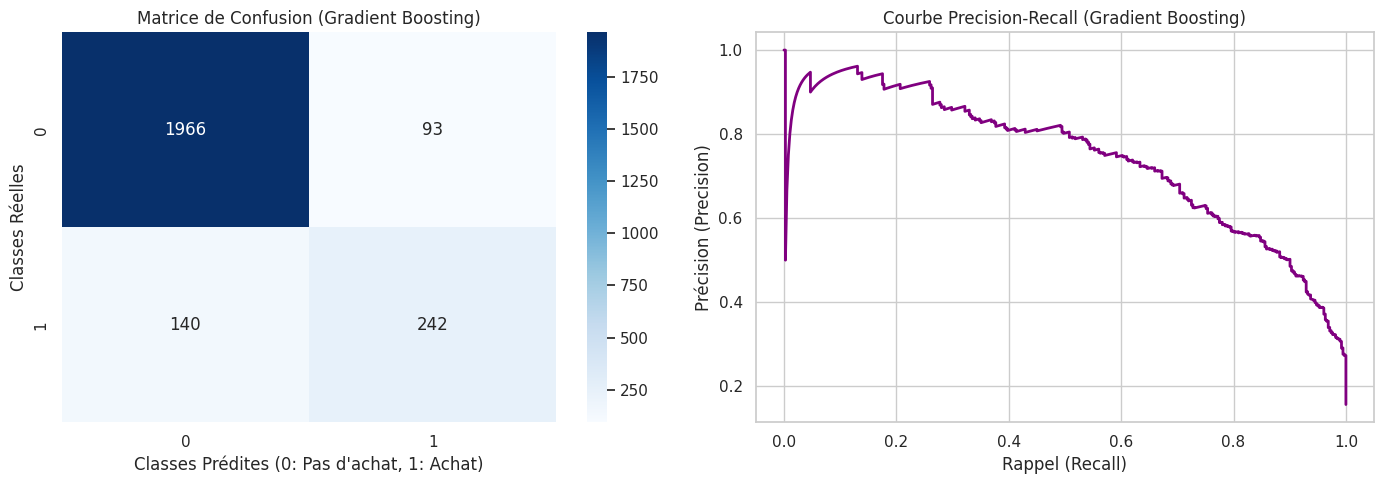

In [12]:
# Sélection automatique du meilleur modèle basé sur le PR-AUC
best_model_name = df_results.sort_values(by='PR-AUC', ascending=False).iloc[0]['Modèle']
print(f"Génération des figures pour le meilleur modèle : {best_model_name}")

# Configuration des graphiques
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Figure 1 : Matrice de confusion
cm = confusion_matrix(y_test, predictions[best_model_name])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Matrice de Confusion ({best_model_name})')
axes[0].set_xlabel('Classes Prédites (0: Pas d\'achat, 1: Achat)')
axes[0].set_ylabel('Classes Réelles')

# Figure 2 : Courbe Precision-Recall (PR Curve)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, probabilities[best_model_name])
axes[1].plot(recall_curve, precision_curve, color='purple', lw=2)
axes[1].set_title(f'Courbe Precision-Recall ({best_model_name})')
axes[1].set_xlabel('Rappel (Recall)')
axes[1].set_ylabel('Précision (Precision)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 10. 10_interpretation_and_limits
Dans cette dernière partie, nous allons extraire l'importance des variables (Feature Importance) de notre meilleur modèle pour comprendre ce qui pousse un utilisateur à l'achat. Nous ajusterons également le seuil de décision pour répondre à un enjeu métier, et nous proposerons des recommandations marketing.

/tmp/ipykernel_1132/1120885544.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='viridis')


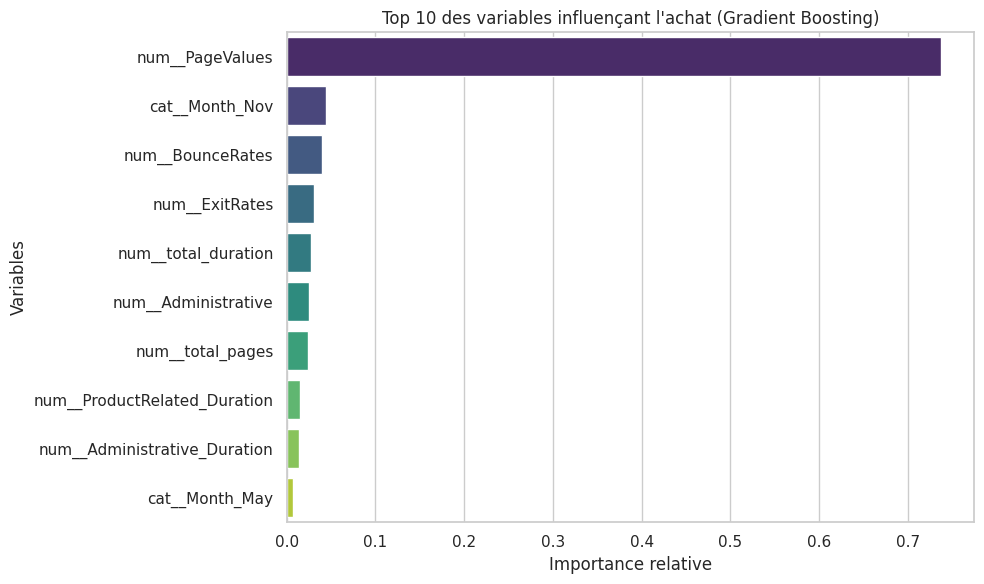

In [13]:
# 1. Extraction de l'importance des features du meilleur modèle (Gradient Boosting)
best_model = models[best_model_name]

# Récupération des noms des colonnes à la sortie du pipeline
feature_names = preprocessor.get_feature_names_out()

# Création d'un DataFrame pour une manipulation facile
importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 2. Affichage visuel du Top 10
plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='viridis')
plt.title(f'Top 10 des variables influençant l\'achat ({best_model_name})')
plt.xlabel('Importance relative')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

In [14]:
# Extension avancée : Ajustement du seuil de décision
# Par défaut, le seuil est de 0.5. Si la probabilité > 0.5, on prédit 1 (Achat).
# Pour un site e-commerce, rater un acheteur (Faux Négatif) coûte souvent plus cher
# que de cibler par erreur un non-acheteur (Faux Positif). On va donc baisser le seuil à 0.2.

seuil_personnalise = 0.2
probabilites_achat = probabilities[best_model_name]
predictions_ajustees = (probabilites_achat >= seuil_personnalise).astype(int)

print("--- Rapport de classification avec seuil par défaut (0.5) ---")
print(classification_report(y_test, predictions[best_model_name]))

print("\n--- Rapport de classification avec seuil ajusté (0.2) ---")
print(classification_report(y_test, predictions_ajustees))

--- Rapport de classification avec seuil par défaut (0.5) ---
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2059
           1       0.72      0.63      0.68       382

    accuracy                           0.90      2441
   macro avg       0.83      0.79      0.81      2441
weighted avg       0.90      0.90      0.90      2441


--- Rapport de classification avec seuil ajusté (0.2) ---
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      2059
           1       0.57      0.82      0.67       382

    accuracy                           0.87      2441
   macro avg       0.76      0.85      0.79      2441
weighted avg       0.90      0.87      0.88      2441



### Discussion Marketing et Recommandations (Obligatoire)

**Interprétation des résultats :**
D'après l'analyse de l'importance des variables, la métrique `PageValues` (la valeur moyenne des pages visitées avant la finalisation de la transaction) est le facteur prédictif d'achat le plus puissant. De plus, nos variables dérivées comme `total_duration` et l'engagement sur les pages produits (`ProductRelated`) jouent un rôle crucial.

**Actions d'optimisation proposées :**
1. **Mettre en valeur les pages à fort "PageValues" :** Identifier les pages spécifiques qui contribuent à un PageValues élevé et diriger le trafic vers ces pages via des bannières ou des recommandations.
2. **Retenir l'attention (total_duration) :** Enrichir les pages produits (vidéos de démonstration, avis clients interactifs, photos 360°) pour augmenter le temps de session des utilisateurs, ce qui augmente mathématiquement la probabilité d'achat.
3. **Récupération des abandons (Stratégie sur le seuil) :** En abaissant le seuil de décision de notre modèle (ex: à 0.2 au lieu de 0.5), nous augmentons le "Recall" (Rappel). Nous captons ainsi plus d'acheteurs potentiels hésitants. Nous pouvons automatiser l'envoi d'un code promo de -5% (sous forme de pop-up) à tous les utilisateurs dont la probabilité d'achat dépasse 20%, afin de forcer la conversion avant qu'ils ne quittent le site.

**Limites du projet :**
L'historique ne prend pas en compte le contexte macro-économique, ni la qualité intrinsèque des produits vendus. De plus, les données de navigation peuvent être altérées par l'utilisation de bloqueurs de publicités (Adblockers) ou de cookies refusés.